# Kuramoto exploration

In [136]:
import infotopo_no_prints
import xgi
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import Bunch
from scipy.integrate import solve_ivp

In [137]:
# Normalize the first two columns individually for a given dataframe (range 0-1)
def normalize_columns(df):
    # Normalize first column (index 0)
    min_x, max_x = df.iloc[:, 0].min(), df.iloc[:, 0].max()
    df.iloc[:, 0] = (df.iloc[:, 0] - min_x) / (max_x - min_x) if max_x != min_x else 0
    
    # Normalize second column (index 1)
    min_y, max_y = df.iloc[:, 1].min(), df.iloc[:, 1].max()
    df.iloc[:, 1] = (df.iloc[:, 1] - min_y) / (max_y - min_y) if max_y != min_y else 0
    
    return df

# Optimized function to compute TSE complexity
def compute_tse_complexity(TC_dict):
    """
    Computes the TSE complexity given a dictionary of total correlations.
    
    Parameters:
        TC_dict (dict): Dictionary of total correlations where keys are tuples (subsets).
        
    Returns:
        float: The TSE complexity.
    """
    N = max(len(subset) for subset in TC_dict)  # Maximum subset size
    TSE = 0
    for gamma in range(1, N):
        TC_full = (gamma / N) * TC_dict[tuple(range(1, N + 1))]
        E_TC_gamma = np.mean([TC_dict[subset] for subset in TC_dict if len(subset) == gamma])
        TSE += TC_full - E_TC_gamma
    return TSE

# Convert pandas dataframe to bunch object
def dataframe_to_bunch(dataframe, target=None, feature_names=None, target_names=None, descr="Custom dataset"):
    if feature_names is None:
        feature_names = dataframe.columns.tolist()
    
    return Bunch(
        data=dataframe.to_numpy(),
        target=target if target is not None else np.zeros(dataframe.shape[0]),
        feature_names=feature_names,
        target_names=target_names if target_names is not None else ["target"],
        DESCR=descr
    )

# Obtain topological information metrics using infotopo
def obtain_infotopo_metrics(dataset, dimension_max=0, dimension_tot=0):

    if dimension_max == 0:
        dimension_max = 3 #dataset.shape[1]
    if dimension_tot == 0:
        dimension_tot = 9 #dataset.shape[1]
    
    sample_size = dataset.shape[0]
    nb_of_values = 16
    forward_computation_mode = True
    work_on_transpose = False
    supervised_mode = False
    sampling_mode = 1
    deformed_probability_mode = False

    information_topo = infotopo_no_prints.infotopo(dimension_max = dimension_max,
                                dimension_tot = dimension_tot,
                                sample_size = sample_size,
                                work_on_transpose = work_on_transpose,
                                nb_of_values = nb_of_values,
                                sampling_mode = sampling_mode,
                                deformed_probability_mode = deformed_probability_mode,
                                supervised_mode = supervised_mode,
                                forward_computation_mode = forward_computation_mode)
    
    Nentropie = information_topo.simplicial_entropies_decomposition(dataset)
    Ninfomut = information_topo.simplicial_infomut_decomposition(Nentropie)
    Nfree_energy = information_topo.total_correlation_simplicial_lanscape(Nentropie)
    
    return  Nentropie, Ninfomut, Nfree_energy

# Function to compute metrics for a time window sliding over a given timeseries
def interactions_values_relative(df_input, window_size=0, window_step=0, dimension_max=0, dimension_tot=0):
    # Initialize an empty DataFrame
    columns = ['R_sum', 'S_sum', 'TSE_value', 'R_std', 'S_std', 'TC_lists']
    df_output = pd.DataFrame(columns=columns)

    # Set initial window conditions
    if window_size == 0:
        window_size = len(df_input)-1
    if window_step == 0:
        window_step = 1
    window_start = 0
    window_end = window_start + window_size

    while window_end < len(df_input):
        bunch_data = dataframe_to_bunch(df_input.iloc[window_start:window_end])
        Nentropie, Ninfomut, Nfree_energy = obtain_infotopo_metrics(bunch_data.data, dimension_max, dimension_tot)

        S_values = [(TC - MI) / 2 for TC, MI in zip(Nfree_energy.values(), Ninfomut.values())]
        R_values = [(TC + MI) / 2 for TC, MI in zip(Nfree_energy.values(), Ninfomut.values())]
        S_std = np.std(S_values, ddof=1)
        R_std = np.std(R_values, ddof=1)
        S_sum = sum(S_values)
        R_sum = sum(R_values)
        TSE_value = compute_tse_complexity(Nfree_energy)

        # Add the new values to the dataframe
        new_row = pd.DataFrame({'R_sum': [R_sum], 'S_sum': [S_sum], 'TSE_value': [TSE_value], 'R_std': [R_std], 'S_std':[S_std], 'TC_lists':[Ninfomut]})
        df_output = pd.concat([df_output, new_row], ignore_index=True)
        
        window_start += window_step
        window_end += window_step

    # Normalize all the values so that the S and R values are all positive and the maximum R and S are 1 and minimum 0.
    min_R = df_output.iloc[:, 0].min()
    df_output.iloc[:, 0] += abs(min_R)

    df_output['S_sum'] = (df_output['S_sum'] - df_output['S_sum'].min()) / (df_output['S_sum'].max() - df_output['S_sum'].min())
    df_output['R_sum'] = (df_output['R_sum'] - df_output['R_sum'].min()) / (df_output['R_sum'].max() - df_output['R_sum'].min())

    return df_output

# Simulate Kuramoto model for high order interactions with XGI
def simulate_kuramoto_xgi(H, K2, K3, T=20, dt=0.01):
    timesteps = int(T / dt)
    H_int = xgi.convert_labels_to_integers(H, "label")
    
    links = H_int.edges.filterby("size", 2).members()
    triangles = H_int.edges.filterby("size", 3).members()
    n = H_int.num_nodes

    theta_time = np.zeros((timesteps, n))
    times = np.arange(timesteps) * dt

    omega = np.random.normal(0, 1, n)
    theta = np.random.random(n) * 2 * np.pi

    # Create adjacency structures
    A2 = np.zeros((n, n))
    for i, j in links:
        A2[i, j] = 1
        A2[j, i] = 1

    A3 = np.zeros((n, n, n))
    for i, j, k in triangles:
        A3[i, j, k] = 1
        A3[i, k, j] = 1
        A3[j, i, k] = 1
        A3[j, k, i] = 1
        A3[k, i, j] = 1
        A3[k, j, i] = 1

    for t in range(timesteps):
        theta_time[t] = theta
        d_theta = np.zeros(n)

        for i in range(n):
            # Pairwise interaction
            for j in range(n):
                if A2[i, j]:
                    d_theta[i] += K2 * np.sin(theta[j] - theta[i])

            # Triadic interaction
            for j in range(n):
                for k in range(n):
                    if A3[i, j, k]:
                        d_theta[i] += K3 * np.sin(theta[j] + theta[k] - 2 * theta[i])

        theta += (omega + d_theta) * dt

    frequencies_df = pd.DataFrame(theta_time, index=times)
    return frequencies_df, theta_time

In [ ]:
# Compute order parameter from theta time series
def compute_order_parameter(theta_time):
    return np.abs(np.mean(np.exp(1j * theta_time), axis=1))

# Main simulation sweep
N = 8
T = 10
dt = 0.01
K_vals = np.linspace(0, 10, 100)
avg_r_vals = []

# Initialize empty hypergraph
H = xgi.Hypergraph()
H.add_nodes_from(range(N))

# Add all possible edges of size 2 to max_dim (inclusive)
for k in range(2, max_dim + 1):
    for edge in itertools.combinations(range(N), k):
        H.add_edge(edge)

# Loop through K values
for K in K_vals:
    K2 = K / N
    K3 = K / N
    theta_time = simulate_kuramoto_xgi(H, K2, K3, T, dt)[1]
    r_t = compute_order_parameter(theta_time)
    avg_r = np.mean(r_t[int(0.5 * len(r_t)):])  # exclude transient
    avg_r_vals.append(avg_r)

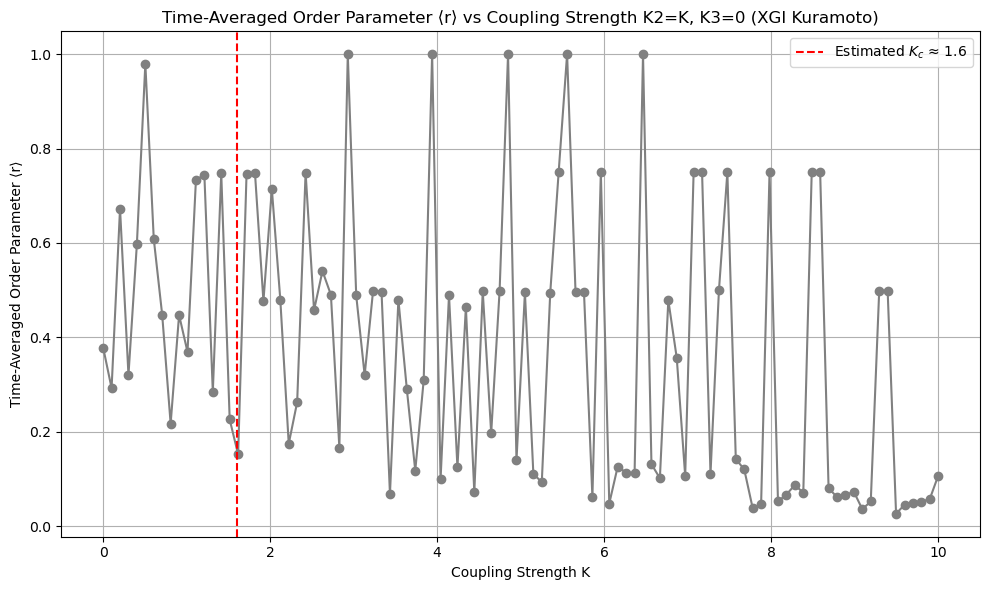

In [82]:
# Fit a smooth average line using a polynomial (e.g., degree 3)
coeffs = np.polyfit(K_vals, avg_r_vals, deg=3)
poly_fit = np.poly1d(coeffs)
smooth_r_vals = poly_fit(K_vals)

# Plot the result
plt.figure(figsize=(10, 6))
plt.plot(K_vals, avg_r_vals, marker='o', color='gray', alpha=1)
# plt.plot(K_vals, smooth_r_vals, color='red', linewidth=2)
plt.axvline(x=1.6, linestyle='--', color='red', label='Estimated $K_c$ ≈ 1.6')
plt.title("Time-Averaged Order Parameter ⟨r⟩ vs Coupling Strength K2=K, K3=0 (XGI Kuramoto)")
plt.xlabel("Coupling Strength K")
plt.ylabel("Time-Averaged Order Parameter ⟨r⟩")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [138]:
# Parameters
N = 10   # Number of oscillators
K = 3.0  # Coupling strength
T = 10   # Total time
dt = 0.01  # Time step
K2 = K/N # Pairwise coupling
K3 = 0  # Triplet coupling
n_simulations = 1
max_dim = 3 # dimension max of hypergraph

# Initialize empty hypergraph
H = xgi.Hypergraph()
H.add_nodes_from(range(N))

# Add all possible edges of size 2 to max_dim (inclusive)
for k in range(2, max_dim + 1):
    for edge in itertools.combinations(range(N), k):
        H.add_edge(edge)

# Run n simulations of the same settings
for n in range(n_simulations):
    # Run the simulation
    frequencies_df = simulate_kuramoto_xgi(H, K2, K3, T, dt)
    # frequencies_df = simulate_kuramoto(N, K2, T, dt)

    # Obtain information metrics
    window_size = 400
    window_step = 6
    dimension_max = 6
    dimension_tot = 6

    df_oscillators = interactions_values_relative(frequencies_df, window_size, window_step, dimension_max, dimension_tot)

In [139]:
df_oscillators

,R_sum,S_sum,TSE_value,R_std,S_std,TC_lists


In [99]:
# Re-import required libraries after code execution environment reset
import pandas as pd

# Load the CSV file into a pandas DataFrame
file_path = 'Data/Kuramoto_data/XGI/kuramoto_frequencies_timeseries_N10_K0.1_T10_1.csv'
df = pd.read_csv(file_path)

# Display the first few rows
df.head()


,osc_0,osc_1,osc_2,osc_3,osc_4,osc_5,osc_6,osc_7,osc_8,osc_9
0,0.485406,1.897422,0.012430,-0.632090,-0.136059,-0.846444,-0.558780,-0.966528,0.719583,-0.454225
1,0.485396,1.897331,0.012502,-0.631975,-0.136034,-0.846581,-0.558757,-0.966505,0.719587,-0.454247
2,0.485376,1.897147,0.012643,-0.631745,-0.135987,-0.846855,-0.558716,-0.966455,0.719596,-0.454289
3,0.485355,1.896958,0.012780,-0.631515,-0.135942,-0.847125,-0.558679,-0.966397,0.719607,-0.454326
4,0.485335,1.896765,0.012914,-0.631285,-0.135902,-0.847392,-0.558647,-0.966334,0.719620,-0.454359


In [115]:
frequencies_df = pd.read_csv('Data\Kuramoto_data\XGI\kuramoto_frequencies_timeseries_N10_K3.0_T10_2.csv')

# Obtain information metrics
window_size = 400
window_step = 6
dimension_max = 6
dimension_tot = 6

df_oscillators = interactions_values_relative(frequencies_df, window_size, window_step, dimension_max, dimension_tot)

<>:1: SyntaxWarning: invalid escape sequence '\K'
<>:1: SyntaxWarning: invalid escape sequence '\K'
C:\Users\cyril\AppData\Local\Temp\ipykernel_365748\4235669493.py:1: SyntaxWarning: invalid escape sequence '\K'
  frequencies_df = pd.read_csv('Data\Kuramoto_data\XGI\kuramoto_frequencies_timeseries_N10_K3.0_T10_2.csv')
C:\Users\cyril\AppData\Local\Temp\ipykernel_365748\4244842013.py:105: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_output = pd.concat([df_output, new_row], ignore_index=True)


In [128]:
data = df_oscillators["TC_lists"][0]
# data = ast.literal_eval(data)

# Count occurrences of each key length
length_counts = {}

for key in data.keys():
    length = len(key)  # Get length of the tuple (key)
    length_counts[length] = length_counts.get(length, 0) + 1

# Initialize variables
cumulative_sum = 0
orders_list = []

# Iterate through dictionary values and compute cumulative sums
for value in length_counts.values():
    cumulative_sum += value  # Add current value to the cumulative sum
    orders_list.append(cumulative_sum)  # Store the cumulative sum

# Convert keys to strings and store in a list
keys_list = [str(key) for key in length_counts.keys()]

KeyError: 0

C:\Users\cyril\AppData\Local\Temp\ipykernel_365748\1877430228.py:73: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


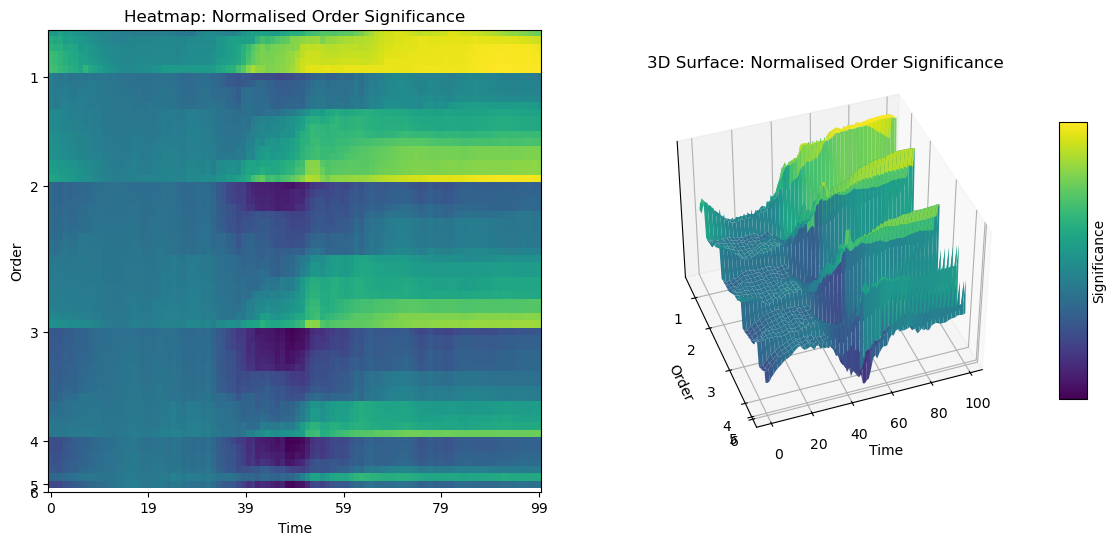

In [118]:
# Define data directly as a list of lists
data = []

for TC_dictionary in df_oscillators['TC_lists']:
    # TC_dictionary = ast.literal_eval(TC_dictionary)
    sorted_dict = dict(sorted(TC_dictionary.items(), key=lambda item: (len(item[0]), item[1])))
    data.append(list(sorted_dict.values()))

# Convert to NumPy array
data = np.array(data)

# Keep only the first part
data = data[:]

# Define time and order indices
x = np.arange(data.shape[0])  # Time steps
y = np.arange(data.shape[1])  # Order indices
X, Y = np.meshgrid(x, y, indexing="xy")  # Corrected meshgrid orientation
Z = data.T  # Transpose to align with heatmap orientation

# Create figure with two subplots (side-by-side)
fig = plt.figure(figsize=(14, 6))

### First Plot (Heatmap) ###
ax1 = fig.add_subplot(1, 2, 1)  # First subplot

cax = ax1.imshow(data.T, aspect='auto', cmap='viridis', origin='lower')

# Remove colorbar for first plot
# cbar1 = fig.colorbar(cax, ax=ax1, label="Significance")  # <- This line is removed

# Set x-axis (time)
ax1.set_xlabel("Time")
ax1.set_xticks(np.linspace(0, data.shape[0] - 1, 6))
ax1.set_xticklabels(np.linspace(0, data.shape[0] - 1, 6, dtype=int))

# Set y-axis (order)
ax1.set_ylabel("Order")
ax1.set_yticks(orders_list)
ax1.set_yticklabels(keys_list)
ax1.set_title("Heatmap: Normalised Order Significance")

ax1.invert_yaxis()  # Invert y-axis direction

### Second Plot (3D Surface) ###
ax2 = fig.add_subplot(1, 2, 2, projection='3d')  # Second subplot

# Set the view angle
ax2.view_init(elev=40, azim=-110)

# Create surface plot
surf = ax2.plot_surface(X, Y, Z, cmap='viridis')

# Add colorbar only to the second plot
cbar2 = fig.colorbar(surf, ax=ax2, shrink=0.6, aspect=10, pad=0.1, label="Significance")

# Remove numbers from the colorbar
cbar2.set_ticks([])  # This removes the tick marks
cbar2.ax.set_yticklabels([])  # This removes the tick labels

# Set y-axis ticks and labels
ax2.set_yticks(orders_list)
ax2.set_yticklabels(keys_list)
ax2.invert_yaxis()  # **Ensure y-axis matches heatmap**

# Labels
ax2.set_xlabel("Time")
ax2.set_ylabel("Order")
ax2.set_zticks([])  # Remove z-axis ticks
ax2.set_title("3D Surface: Normalised Order Significance")

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

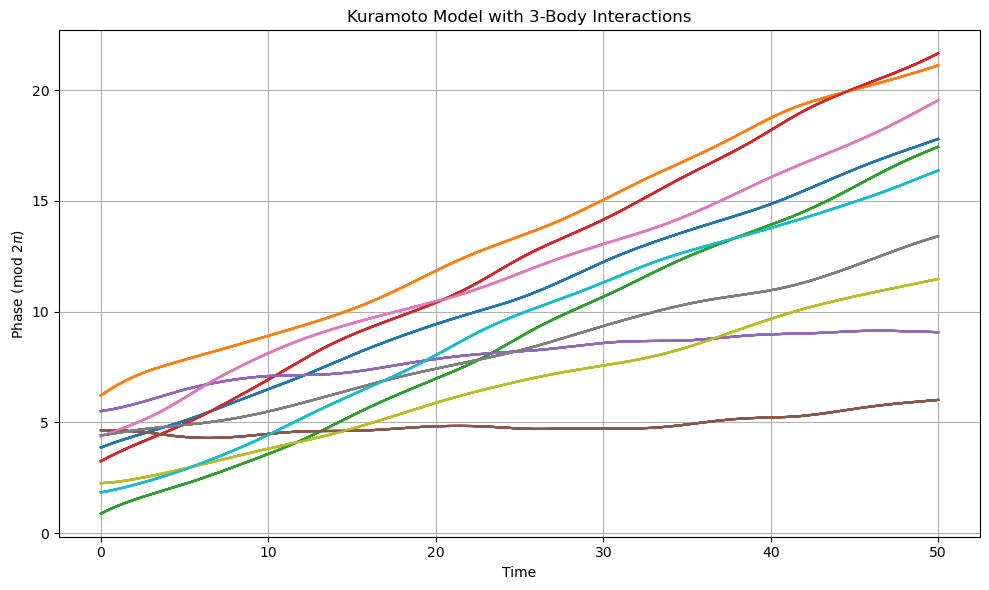

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
N = 10  # Number of oscillators
K2 = 3  # Coupling strength for 3-body interaction
T = 50  # Total time
dt = 0.01
t = np.arange(0, T, dt)

# Random initial phases and frequencies
theta0 = 2 * np.pi * np.random.rand(N)
omega = 0.5 * (2 * np.random.rand(N) - 1)  # Random frequencies in [-0.5, 0.5]

# Define a fully connected 3-simplex tensor: A[i,j,k] = 1 if i,j,k are distinct
A = np.zeros((N, N, N))
for i in range(N):
    for j in range(N):
        for k in range(N):
            if len(set([i, j, k])) == 3:
                A[i, j, k] = 1

def kuramoto_high_order(theta, t, omega, K2, A):
    dtheta = np.zeros(N)
    for i in range(N):
        coupling_sum = 0
        for j in range(N):
            for k in range(N):
                if A[i, j, k]:
                    coupling_sum += np.sin(theta[j] + theta[k] - 2 * theta[i])
        dtheta[i] = omega[i] + (K2 / N**2) * coupling_sum
    return dtheta

# Integrate the ODEs
theta = odeint(kuramoto_high_order, theta0, t, args=(omega, K2, A))

# Plot the phases over time
plt.figure(figsize=(10, 6))
for i in range(N):
    # plt.plot(t, np.mod(theta[:, i], 2*np.pi), label=f'Oscillator {i+1}')
    plt.plot(t, theta, label=f'Oscillator {i+1}')
plt.xlabel('Time')
plt.ylabel('Phase (mod $2\\pi$)')
plt.title('Kuramoto Model with 3-Body Interactions')
plt.grid(True)
plt.tight_layout()
plt.show()
